**Step 1: importing the libraries needed**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

**Step 2:Loading the data-set**

In [60]:
df=pd.read_csv("../data/Telco-Customer-Churn.csv")

**Step 3:validating the data set loaded**

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Step 4:Initial Data Exploration**

In [4]:
df.shape #so we should have 7043 customers and 21 variables(featurs)

(7043, 21)

In [5]:
df.columns #column names

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Step 5: Data Cleaning**

In [7]:
#changing Totalcharges dtype to float64 and making sure the column with " " marked as NaN without getting crashed
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [8]:
df['TotalCharges'].dtype

dtype('float64')

In [9]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [10]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [12]:
#Binary encoding the 'Churn' column to make it compatible with ML algorithms
df['Churn']=df['Churn'].map({'Yes': 1, 'No': 0})

In [13]:
df['Churn'].unique()

array([0, 1])

**Step 6:EDA**

In [14]:
#how many customers is actually churned , is there a big number to be consider about the it?
total_cus=df.shape[0]
total_cus

7043

In [15]:
#so 7043 total customers
#sum of 1's in churn
churned=df['Churn'].sum()
churned

np.int64(1869)

In [16]:
#1869 customers is churned !
#percentage of churn
per_of_churn=(churned/total_cus)*100
per_of_churn


np.float64(26.536987079369588)

**Observation:** As we can see here 26.53% of the customers are leaving from the company, which is a huge number and even very threatening the future  existence of the company , We have to immediatly find out what the cause , and what we can do to solve the issue.

In [17]:
#Creating a pie chart for clear visual understanding of the impact of churn in the business
not_churned=total_cus-churned
not_churned

np.int64(5174)

Text(0.5, 1.0, 'Customer Churn Percentage')

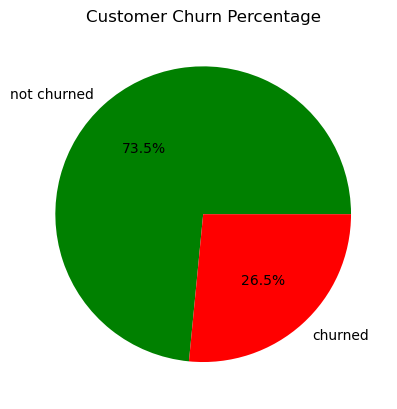

In [18]:
plt.pie(x=[not_churned,churned], labels=['not churned','churned'], autopct='%1.1f%%',colors=['green','red'] )

plt.title("Customer Churn Percentage")

As identified earlier, 26.5% of customers have churned. To provide a clearer understanding of the impact, the pie chart has been prepared with red representing churned customers and green representing retained customers.

In [19]:
#why customers churned ?
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [20]:
# I think the most probable factores of this are -PhoneService,TechSupport,Contract,MonthlyCharges,internetService
#even though PhoneService,TechSupport and internetService service is less reason to be churned 
#so i am going with Contract and MonthlyCharges.
df.groupby('Contract')['Churn'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

**Observation:** shorter contracts like Month to month have the highest churn rate 42.7 percentage and As the contract period getting longer the Churn rate is become less , for one year 11.26% , Two year 2%

**Recommendation:** Need to encourage shorter contract customers change to longer contracts:

**1**.Can check an option to give special promotional offers to the customers on shorter contract especially when the last month of the contract end.
**2**.Need to discuss about giving less payment plan for long term contracts

Text(0.5, 1.0, 'Charges relation to churn')

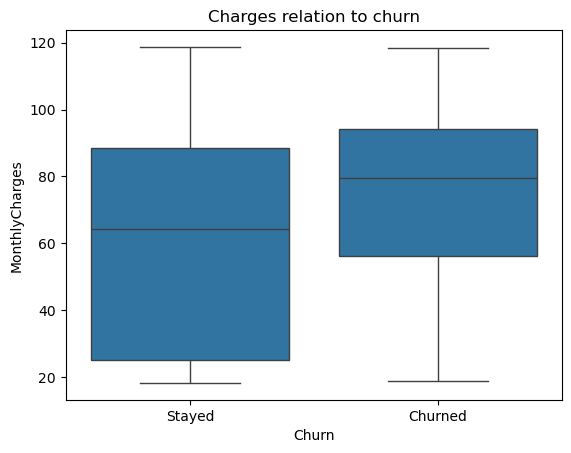

In [21]:
#Creating a Box plot to easly compare and understand the churned and stayed groups with parameter of mothly charges.

sns.boxplot(x=df['Churn'],y=df['MonthlyCharges'])
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.title('Charges relation to churn')

**Observation:** The Box plot information clearly shows that customers who are paying more charges 
are churned , they are paying average of 80 dollars/month but who ever is stayed are paying average 
65 dollars/month. 
So it clearly showing that high monthly charges is equal to most likely churn and others are staying

**Recommendation:** Need to make the high paying customers feel the package valuable, not just coverage which all the customers get. We can add value by giving bundles like Netflix premium, or spotify premium or providing a single premium plan of youtube will give access to both the largest library of videos and music including YT music, which I also think it increase profit of the company, because providing two premium plans of two big companies is cheaper than providing one plan of one company. 

In [22]:
#checking at what point (tenure) the customers are leaving the most
#filtering creating a new data set only with churned customers 
churned_df=df[df['Churn']==1]


In [23]:
churned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1869 entries, 2 to 7041
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1869 non-null   object 
 1   gender            1869 non-null   object 
 2   SeniorCitizen     1869 non-null   int64  
 3   Partner           1869 non-null   object 
 4   Dependents        1869 non-null   object 
 5   tenure            1869 non-null   int64  
 6   PhoneService      1869 non-null   object 
 7   MultipleLines     1869 non-null   object 
 8   InternetService   1869 non-null   object 
 9   OnlineSecurity    1869 non-null   object 
 10  OnlineBackup      1869 non-null   object 
 11  DeviceProtection  1869 non-null   object 
 12  TechSupport       1869 non-null   object 
 13  StreamingTV       1869 non-null   object 
 14  StreamingMovies   1869 non-null   object 
 15  Contract          1869 non-null   object 
 16  PaperlessBilling  1869 non-null   object 
 17  

<Axes: xlabel='tenure', ylabel='Count'>

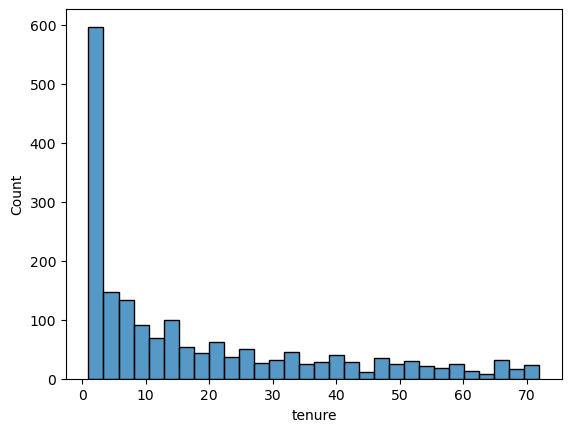

In [24]:
#creating a histogram
sns.histplot(data=churned_df,x='tenure',bins=30)

Observation: The histogram shows a clear trend of churning on shorter period of tenure, from left to right when the tenure getting longer the churning rate of customers is also getting reduced, and it shows a clear stability of customers starting from 20 months (x-axis) and less than 10 months shows clear instability. So I will say 10 to 20 months is the decision making time frame.
Also as an add on I will call the customers under 0-10 months as 'Starting Section', and 10 to 20 as 'Decision Section' and others as 'Stable Section'.
Recommendation: We have to focus on the customers that come under the Starting Section and Decision Section, if we can get the customers to the Stable Section it is the win for us. So we have to make plans for targeting customers under these 2 sections.

**step 7 Feature Engineering**

In [25]:
#starting by analysing the data set and making the changes needed.
#droping customerID column 
df=df.drop(columns=['customerID'],errors='ignore')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


As we can see the 'customerID' column has been droped, now we need to convert all necessary text columns to numbers to make it compatible with ML algorithms . There are two types of encoding used:Binary Encoding,for columns with only two categories (Yes/No, Male/Female) mapped to 1/0, and One Hot Encoding for columns with more than two categories it creates separate 1/0 column for each category.
So,as per our data set
Columns i am choosing for Binory Encoding : Partner, Dependents, PhoneService, PaperlessBilling, gender.
And for One Hot Encoding is Contract, PaymentMethod, InternetService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

**Binory Encoding**

In [27]:
#confirming the unique values in the columns fo binory encoding
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [28]:
df['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [29]:
df['PhoneService'].unique()

array(['No', 'Yes'], dtype=object)

In [30]:
df['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [31]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [32]:
#Now start with binary encoding to each column 
#Partner
df['Partner']=df['Partner'].map({'Yes':1,'No':0})

In [33]:
#Dependents
df['Dependents']=df['Dependents'].map({'Yes':1,'No':0})

In [34]:
#PhoneService
df['PhoneService']=df['PhoneService'].map({'Yes':1,'No':0})

In [35]:
#PaperlessBilling
df['PaperlessBilling']=df['PaperlessBilling'].map({'Yes':1,'No':0})

In [36]:
#gender
df['gender']=df['gender'].map({'Female':1,'Male':0})

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [38]:
#Now Confirming the columns for ONe Hot Encoding
OneHot_collist=['Contract','PaymentMethod','InternetService', 
            'MultipleLines','OnlineSecurity','OnlineBackup', 
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in OneHot_collist:
    print(col,":",df[col].unique(),"\n")



Contract : ['Month-to-month' 'One year' 'Two year'] 

PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 

InternetService : ['DSL' 'Fiber optic' 'No'] 

MultipleLines : ['No phone service' 'No' 'Yes'] 

OnlineSecurity : ['No' 'Yes' 'No internet service'] 

OnlineBackup : ['Yes' 'No' 'No internet service'] 

DeviceProtection : ['No' 'Yes' 'No internet service'] 

TechSupport : ['No' 'Yes' 'No internet service'] 

StreamingTV : ['No' 'Yes' 'No internet service'] 

StreamingMovies : ['No' 'Yes' 'No internet service'] 



In [39]:
#One Hot Encoding
df=pd.get_dummies(df,columns=OneHot_collist)

In [40]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,1,0,1,0,1,0,1,29.85,29.85,0,...,False,True,False,False,True,False,False,True,False,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,True,True,False,False,True,False,False,True,False,False
2,0,0,0,0,2,1,1,53.85,108.15,1,...,False,True,False,False,True,False,False,True,False,False
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,True,True,False,False,True,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,False,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,...,True,False,False,True,False,False,True,False,False,True
7039,1,0,1,1,72,1,1,103.20,7362.90,0,...,True,True,False,False,False,False,True,False,False,True
7040,1,0,1,1,11,0,1,29.60,346.45,0,...,False,True,False,False,True,False,False,True,False,False
7041,0,1,1,0,4,1,1,74.40,306.60,1,...,False,True,False,False,True,False,False,True,False,False


In [41]:
#Converting all boolean values to integer (1/0) for consistency and compatibility with all ML algorithms
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  Contract_Month-to-month                  7043 no

**Step 8: Model Building**

In [43]:
#creating features(x) and Target data(y)
y=df['Churn']
X=df.drop(columns=['Churn'])


In [44]:
print(y.shape)
print(X.shape)

(7043,)
(7043, 40)


In [45]:
#splitting the train and test data 

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
print(X_train.shape)
print(X_test.shape)

(5634, 40)
(1409, 40)


In [49]:
#Scaling the data to bring all features to the same range.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression()
model_lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [51]:
print(model_lr)

LogisticRegression()


In [52]:
#prediction using the model
y_pred = model_lr.predict(X_test_scaled)

In [53]:
#getting the accuracy score
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8204400283889283

The model predicts 82% of the customers churned correctly, so it is best to use the model for getting a great understanding of customer mindset and we can use the model for predict the customers who is going to churn an act accordingly, focusd on that particular customers so it will help to retain the customers and get them to the stable section, and also reduce the company investment on unessicorry customers. However add to this, 18% of predictions will be incorrect — meaning some at-risk customers may be missed or some retained customers may be unnecessarily targeted.But ultimatly the modle will be a good co-worker for us.

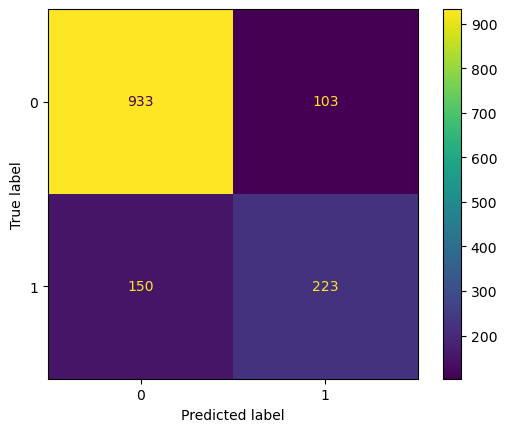

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

**Observation:** While the Logistic Regression model achieves 82% overall accuracy, a deeper look at the confusion matrix reveals that only 60% of actual churners are correctly identified (223 out of 373). This means 150 at-risk customers are missed completely — representing direct revenue loss for the business. Overall accuracy alone is misleading; Recall is the more critical metric for churn prediction.

**Random Forest model**

In [55]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
#accuracy confusion matrix 
y_pred_rf = model_rf.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))

0.7970191625266146


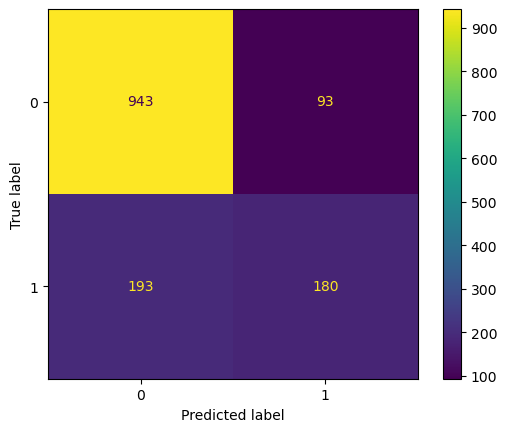

In [58]:
#confusion matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()

**Observation:** Comparing both models, Logistic Regression outperforms Random Forest with 82% accuracy vs 79.7%, and more importantly catches 223 actual churners vs only 180. Logistic Regression is the recommended model for this churn prediction task.

***Step 9: Business Recommendations Summary***
Based on the analysis of 7,043 telecom customers, the following key findings and recommendations have been identified:
1. Churn Rate is Critical-
26.5% of customers are churning — 1 in 4 customers is leaving. Immediate action is required to prevent further revenue loss.

2. Contract Type is the Strongest Predictor-
Month-to-month customers churn at 42.7% vs only 2.8% for two-year contracts. The business should offer promotional discounts to encourage customers to switch to longer contracts, especially at contract renewal time.

3. High Monthly Charges Drive Churn-
Churned customers pay an average of $80/month vs $65 for retained customers. The business should add value through entertainment bundles (YouTube Premium, Spotify) to justify higher pricing and improve retention.

4. New Customers are the Highest Risk-
Customers in the Starting Section (0-10 months) churn the most. Focus retention efforts on moving customers from Starting → Decision → Stable section. Targeted onboarding plans and early loyalty rewards are recommended.

5. Model Recommendation-
Logistic Regression (82% accuracy) is recommended over Random Forest (79.7%) for identifying at-risk customers. The model should be used to proactively target high-risk customers before they churn.